# NGC 4151 Case 1: thermal CPL, Ec=200 keV

Runs 100 Poisson realizations at both 3 and 24 months. For each exposure, it selects the realization closest to the median source-detection TS; equal-distance candidates are ranked by closeness to the median recovered cutoff energy, then by seed.


In [ ]:
from IPython.display import display
from agn_fixed_case_sensitivity import (
    load_sed_handoff,
    plot_fixed_case_ensemble,
    run_fixed_case_ensemble,
)
%matplotlib inline

In [ ]:
case = {
    "case_tag": "Case1_ec200",
    "output_prefix": "NGC4151_ec200_TH",
    "description": "Case 1: thermal CPL, Ec=200 keV",
    "file_stem": "ec_200_DC4_COSI_cpl_60_fovCut",
    "comparison": "source_detection",
    "longitude_deg": 155.077, "latitude_deg": 75.063, "fov_cut_deg": 60.0,
    "fit_pivot_keV": 200.0,
    "primary": {"kind": "cpl", "K": 0.15, "pivot_keV": 1.0, "cutoff_keV": 200.0, "index": -1.75, "fit_index_free": True, "fit_cutoff_free": True},
}
exposure_months_list = (3, 24)
n_seeds = 300
seed_start = 4100
target_delta_ts = 9.0
resume_existing_trials = True

In [ ]:
results = {}
for exposure_months in exposure_months_list:
    print(f"\n=== {exposure_months}-month ensemble ===")
    results[exposure_months] = run_fixed_case_ensemble(
        case, n_seeds=n_seeds, seed_start=seed_start,
        exposure_months=exposure_months, target_delta_ts=target_delta_ts,
        resume_existing_trials=resume_existing_trials,
    )
    display(results[exposure_months]["summary"])
    display(results[exposure_months]["delta_ts_candidates"][[
        "seed", "delta_ts", "delta_ts_distance_from_median",
        "fit_primary_cutoff_keV",
        "recovered_cutoff_keV_distance_from_median",
    ]])


=== 3-month ensemble ===
Loaded 100 checkpointed trials from /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case1_ec200/NGC4151_ec200_TH_trials_3months.csv
Median source detection TS: 447.449
Central 68% range: 253.362-574.163
Fraction >= 9: 1.000
Median recovered_cutoff_keV: 187.4
Delta-TS-primary candidates: 2
Representative seed: 4181
Representative statistic: 445.039
Representative recovered_cutoff_keV: 160.8
Saved median data: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case1_ec200/NGC4151_plus_bkg_ec_200_DC4_COSI_cpl_60_fovCut_3months_medianSeed_4181.hdf5
Saved manifest: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case1_ec200/NGC4151_ec200_TH_median_realization_3months.json


,case_tag,comparison,exposure_months,n_requested_seeds,n_successful_fits,median_delta_ts,delta_ts_q16,delta_ts_q84,target_delta_ts,fraction_delta_ts_ge_target,representative_secondary_criterion,median_recovered_cutoff_keV,representative_seed,representative_delta_ts,representative_recovered_cutoff_keV
0,Case1_ec200,source_detection,3,100,100,447.448648,253.361702,574.163429,9.0,1.0,recovered_cutoff_keV,187.397269,4181,445.039285,160.798615


,seed,delta_ts,delta_ts_distance_from_median,fit_primary_cutoff_keV,recovered_cutoff_keV_distance_from_median
74,4174,449.858012,2.409364,100.013988,87.383282
81,4181,445.039285,2.409364,160.798615,26.598654



=== 24-month ensemble ===



WARNING RuntimeWarning: invalid value encountered in subtract


WARNING RuntimeWarning: invalid value encountered in subtract



Loaded 100 checkpointed trials from /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case1_ec200/NGC4151_ec200_TH_trials_24months.csv
Median source detection TS: 3453.518
Central 68% range: 3106.674-3949.762
Fraction >= 9: 1.000
Median recovered_cutoff_keV: 197.57
Delta-TS-primary candidates: 2
Representative seed: 4152
Representative statistic: 3446.729
Representative recovered_cutoff_keV: 201.16
Saved median data: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case1_ec200/NGC4151_plus_bkg_ec_200_DC4_COSI_cpl_60_fovCut_24months_medianSeed_4152.hdf5
Saved manifest: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case1_ec200/NGC4151_ec200_TH_median_realization_24months.json


,case_tag,comparison,exposure_months,n_requested_seeds,n_successful_fits,median_delta_ts,delta_ts_q16,delta_ts_q84,target_delta_ts,fraction_delta_ts_ge_target,representative_secondary_criterion,median_recovered_cutoff_keV,representative_seed,representative_delta_ts,representative_recovered_cutoff_keV
0,Case1_ec200,source_detection,24,100,100,3453.518168,3106.673513,3949.762275,9.0,1.0,recovered_cutoff_keV,197.565194,4152,3446.728772,201.164889


,seed,delta_ts,delta_ts_distance_from_median,fit_primary_cutoff_keV,recovered_cutoff_keV_distance_from_median
14,4114,3460.307564,6.789396,251.495894,53.930701
52,4152,3446.728772,6.789396,201.164889,3.599695


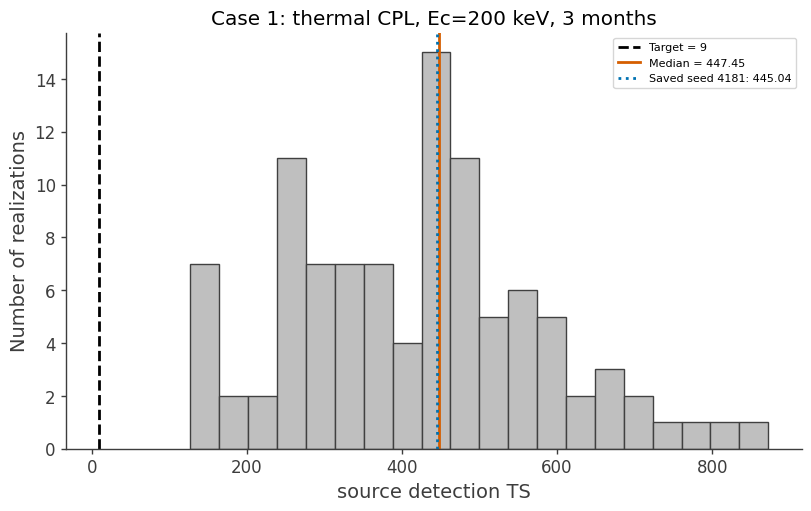

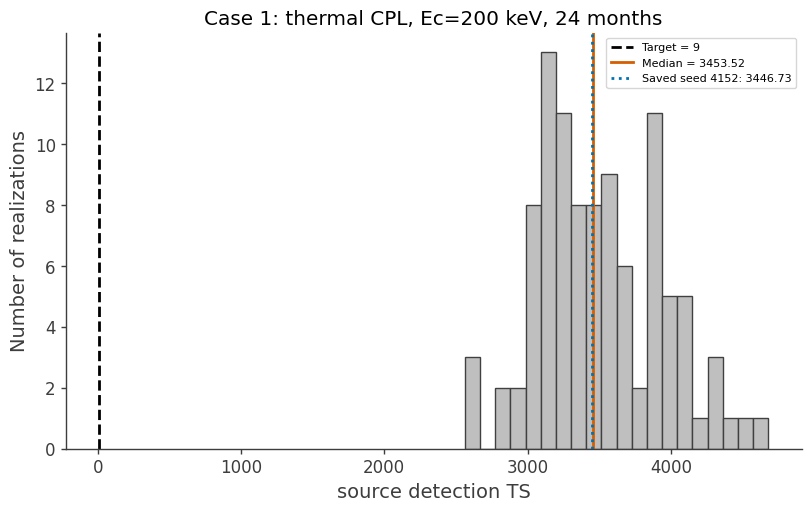

In [ ]:
for exposure_months in exposure_months_list:
    fig, ax = plot_fixed_case_ensemble(results[exposure_months])
    ax.set_title(f"{case['description']}, {exposure_months} months")

In [ ]:
sed_handoffs = {}
for exposure_months in exposure_months_list:
    sed_handoffs[exposure_months] = load_sed_handoff(results[exposure_months]["manifest_file"])
    print(exposure_months, sed_handoffs[exposure_months][0]["median_data_file"])

3 /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case1_ec200/NGC4151_plus_bkg_ec_200_DC4_COSI_cpl_60_fovCut_3months_medianSeed_4181.hdf5
24 /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case1_ec200/NGC4151_plus_bkg_ec_200_DC4_COSI_cpl_60_fovCut_24months_medianSeed_4152.hdf5
